In [5]:
import numpy as np

def cramer_2x2(A, b):
    detA = np.linalg.det(A)

    A1 = A.copy()
    A1[:, 0] = b

    A2 = A.copy()
    A2[:, 1] = b

    x = np.linalg.det(A1) / detA
    y = np.linalg.det(A2) / detA

    return np.array([x, y])


def cramer_3x3(A, b):
    detA = np.linalg.det(A)

    solucao = []

    for i in range(3):
        Ai = A.copy()
        Ai[:, i] = b
        solucao.append(np.linalg.det(Ai) / detA)

    return np.array(solucao)


A = np.array([[2, 1],
              [1, 3]])

b = np.array([5, 6])

print("Sistema 2x2")
print("Cramer =")
print(cramer_2x2(A, b))

print("\nNumPy =")
print(np.linalg.solve(A, b))


A = np.array([[2, 1, -1],
              [-3, -1, 2],
              [-2, 1, 2]])

b = np.array([8, -11, -3])

print("\nSistema 3x3")
print("Cramer =")
print(cramer_3x3(A, b))

print("\nNumPy =")
print(np.linalg.solve(A, b))

Sistema 2x2
Cramer =
[1.8 1.4]

NumPy =
[1.8 1.4]

Sistema 3x3
Cramer =
[ 2.  3. -1.]

NumPy =
[ 2.  3. -1.]


In [6]:
import numpy as np
from scipy.linalg import lu

A = np.array([[2, 1, 1],
              [4, -6, 0],
              [-2, 7, 2]])

P, L, U = lu(A)

print("Matriz A:")
print(A)

print("\nP:")
print(P)

print("\nL:")
print(L)

print("\nU:")
print(U)

print("\nPA:")
print(P @ A)

print("\nLU:")
print(L @ U)

print("\nPA = LU ?")
print(np.allclose(P @ A, L @ U))

det = np.prod(np.diag(U))

print("\nDeterminante:")
print(det)

Matriz A:
[[ 2  1  1]
 [ 4 -6  0]
 [-2  7  2]]

P:
[[0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]]

L:
[[ 1.   0.   0. ]
 [ 0.5  1.   0. ]
 [-0.5  1.   1. ]]

U:
[[ 4. -6.  0.]
 [ 0.  4.  1.]
 [ 0.  0.  1.]]

PA:
[[ 4. -6.  0.]
 [ 2.  1.  1.]
 [-2.  7.  2.]]

LU:
[[ 4. -6.  0.]
 [ 2.  1.  1.]
 [-2.  7.  2.]]

PA = LU ?
True

Determinante:
16.0


Resultados:
n = 2: 0.00006130 s
n = 3: 0.00002850 s
n = 5: 0.00002760 s
n = 10: 0.00002570 s
n = 20: 0.00003840 s
n = 50: 0.00009250 s
n = 100: 0.00017480 s


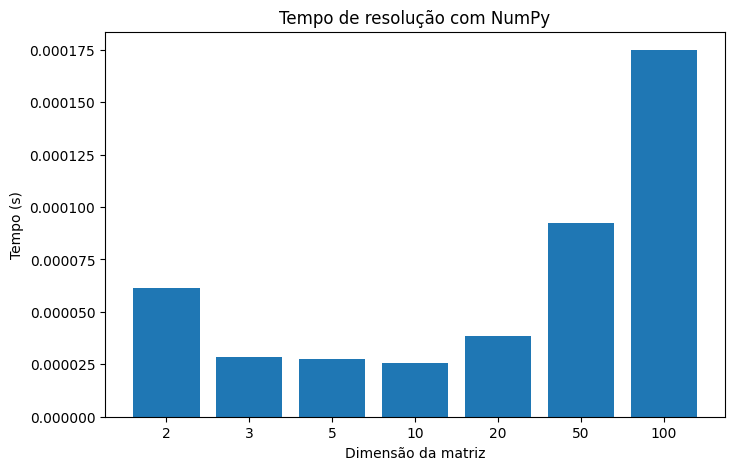

In [11]:
import numpy as np
import time
import matplotlib.pyplot as plt

tamanhos = [2, 3, 5, 10, 20, 50, 100]

tempos_numpy = []

for n in tamanhos:

    A = np.random.rand(n, n)

    while abs(np.linalg.det(A)) < 1e-10:
        A = np.random.rand(n, n)

    b = np.random.rand(n)

    inicio = time.perf_counter()

    np.linalg.solve(A, b)

    fim = time.perf_counter()

    tempos_numpy.append(fim - inicio)

print("Resultados:")

for n, t in zip(tamanhos, tempos_numpy):
    print(f"n = {n}: {t:.8f} s")

plt.figure(figsize=(8,5))
plt.bar([str(n) for n in tamanhos], tempos_numpy)
plt.title("Tempo de resolução com NumPy")
plt.xlabel("Dimensão da matriz")
plt.ylabel("Tempo (s)")
plt.savefig("benchmark.png")
plt.show()

In [12]:
import numpy as np
from scipy.linalg import lu_factor, lu_solve
import time

A = np.array([[4, 2, 1],
              [2, 5, 3],
              [1, 3, 6]])

b1 = np.array([1, 2, 3])
b2 = np.array([4, 5, 6])
b3 = np.array([7, 8, 9])

inicio = time.perf_counter()

lu, piv = lu_factor(A)

x1 = lu_solve((lu, piv), b1)
x2 = lu_solve((lu, piv), b2)
x3 = lu_solve((lu, piv), b3)

fim = time.perf_counter()

print("x1 =")
print(x1)

print("\nx2 =")
print(x2)

print("\nx3 =")
print(x3)

print("\nTempo total:")
print(fim - inicio)

x1 =
[0.08955224 0.10447761 0.43283582]

x2 =
[0.67164179 0.28358209 0.74626866]

x3 =
[1.25373134 0.46268657 1.05970149]

Tempo total:
0.0003635999746620655


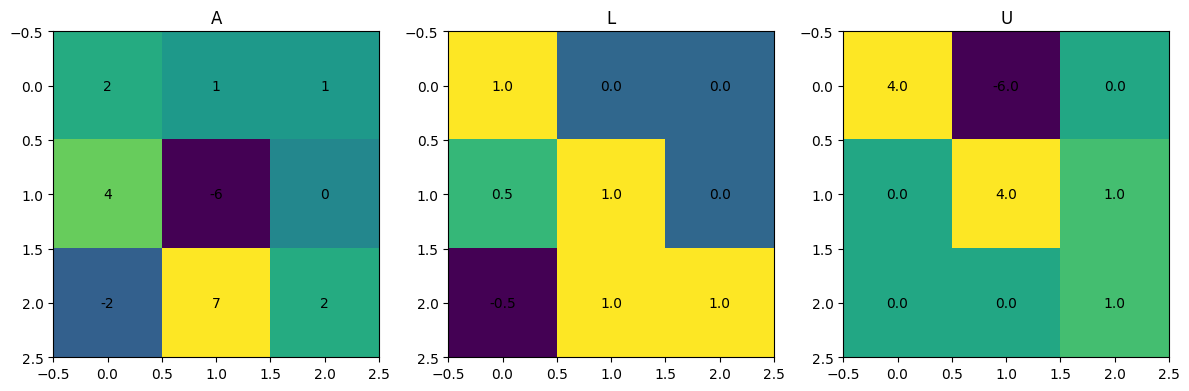

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import lu

A = np.array([[2, 1, 1],
              [4, -6, 0],
              [-2, 7, 2]])

P, L, U = lu(A)

fig, axs = plt.subplots(1, 3, figsize=(12, 4))

axs[0].imshow(A)
axs[0].set_title("A")

axs[1].imshow(L)
axs[1].set_title("L")

axs[2].imshow(U)
axs[2].set_title("U")

for k, matriz in enumerate([A, L, U]):
    for i in range(matriz.shape[0]):
        for j in range(matriz.shape[1]):
            axs[k].text(j, i, round(matriz[i, j], 2),
                        ha="center", va="center")

plt.tight_layout()
plt.savefig("lu_heatmap.png")
plt.show()